In [1]:
print("start")

start


In [2]:
import copy 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import os 
import re
import time
import random

import torch 
import torch.optim as optim 
import torch.nn as nn
import torch.nn.functional as F  
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset, Subset 
from torch.utils.data import WeightedRandomSampler 
from torchvision import transforms

In [3]:
def set_seed(seed=42):
    random.seed(seed)

    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

In [4]:
reports_path = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/indiana_reports.csv"
projection_path = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/indiana_projections.csv"
reports = pd.read_csv(reports_path)
projection_report = pd.read_csv(projection_path)

reports.head()

,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [5]:
df = projection_report.merge(
    reports[["uid", "findings"]],
    on="uid",
    how="inner"
)

In [6]:
projection_report.head()

,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal


In [7]:
df.head()

,uid,filename,projection,findings
0,1,1_IM-0001-4001.dcm.png,Frontal,The cardiac silhouette and mediastinum size ar...
1,1,1_IM-0001-3001.dcm.png,Lateral,The cardiac silhouette and mediastinum size ar...
2,2,2_IM-0652-1001.dcm.png,Frontal,Borderline cardiomegaly. Midline sternotomy XX...
3,2,2_IM-0652-2001.dcm.png,Lateral,Borderline cardiomegaly. Midline sternotomy XX...
4,3,3_IM-1384-1001.dcm.png,Frontal,NaN


In [8]:
image_path = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized"
unique_ids = set()
for file in os.listdir(image_path):
    results = df[df["filename"] == file]
    if results.empty:
        continue
    if results["projection"].iloc[0] != "Frontal":
        continue
    finding = results["findings"].iloc[0]
    if type(finding)!=str:
        continue
    if len(finding) == 0:
        continue
    distinct_id = results["uid"].iloc[0].item()
    unique_ids.add(distinct_id)
print(len(unique_ids))

3199


In [9]:
max_id = -234
for fire in unique_ids:
    max_id = max(fire,max_id)
print(max_id)

3997


In [10]:
x_rays = []
targets = []
for i in range(0,max_id+1):
    x_rays.append([])
    targets.append([])
for file in os.listdir(image_path):
    results = df[df["filename"] == file]
    if results.empty:
        continue
    if results["projection"].iloc[0] != "Frontal":
        continue
    finding = results["findings"].iloc[0]
    if type(finding)!=str:
        continue
    if len(finding) == 0:
        continue
    distinct_id = results["uid"].iloc[0].item()
    if distinct_id not in unique_ids:
        continue
    targets[distinct_id].append(finding)
    img_path = os.path.join(image_path,file)
    x_rays[distinct_id].append(img_path)

In [11]:
unique_id_list = list(unique_ids)

In [12]:
def index_splitter(indices,number,amount,seed=42):
    amount = torch.tensor(amount)
    amount = amount * number
    amount = amount / 100
    amount = amount.int()
    amount[0] += (number-amount.sum())
    g = torch.Generator().manual_seed(seed)
    split1, split2,split3 = random_split(indices,amount,generator=g)
    indices = torch.tensor(indices,dtype=torch.int16)
    split1 = indices[split1.indices]
    split2 = indices[split2.indices]
    split3 = indices[split3.indices]
    return split1,split2,split3

In [13]:
train_indices, val_indices, test_indices = index_splitter(unique_id_list,len(unique_id_list),[90,5,5])

In [14]:
def get_split(indices):
    split_x_rays = []
    split_target = []
    p = len(indices)
    missing = 0 
    for i in range(0,p):
        index = indices[i].item()
        v = len(x_rays[index])
        for j in range(0,v):
            if len(targets[index][j]) == 0:
                missing = missing + 1
            split_x_rays.append(x_rays[index][j])
            split_target.append(targets[index][j])
    print("Misssing:",missing)
    return split_x_rays, split_target

In [15]:
train_x_rays, train_targets = get_split(train_indices)
val_x_rays, val_targets = get_split(val_indices)
test_x_rays, test_targets = get_split(test_indices)

Misssing: 0
Misssing: 0
Misssing: 0


In [16]:
print(train_x_rays[2])
print("################")
print(train_targets[2])
print("$$$$$$$$$$$$$$$$$$$$$$$$$")
print(train_x_rays[3])
print("################")
print(train_targets[3])

/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/2173_IM-0786-1001.dcm.png
################
Cardiac and mediastinal contours are unremarkable. Pulmonary vascularity is within normal limits. No focal air space opacities, pleural effusion, or pneumothorax. Osseous structures are grossly unremarkable. Unchanged degenerative changes to the thoracic spine.
$$$$$$$$$$$$$$$$$$$$$$$$$
/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/551_IM-2154-1001.dcm.png
################
Lungs are hyperinflated with flattening of the diaphragms and increased AP chest diameter, compatible with emphysema. There is no evidence of focal infiltrate, pneumothorax, pleural effusion, or identified mass lesion. There is normal cardiomediastinal contours.


In [17]:
def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\w+|[^\w\s]",text)
    return tokens

In [18]:
q = "sdfs werwe odfgfg"
c1 = Counter()
print(tokenize(q))
print("####################")
c1.update(tokenize(q))
print(c1)

['sdfs', 'werwe', 'odfgfg']
####################
Counter({'sdfs': 1, 'werwe': 1, 'odfgfg': 1})


In [19]:
counter = Counter()

In [20]:
special_tokens = ["<PAD>","<BOS>","<EOS>","<UNK>"]

for text in train_targets:
    counter.update(tokenize(text))

In [21]:
word_to_idx = {}
for word in special_tokens:
    word_to_idx[word] = len(word_to_idx)

for word, frequency in counter.items():
    word_to_idx[word] = len(word_to_idx)
idx_to_word = {}
for word,idx in word_to_idx.items():
    idx_to_word[idx] = word
print(len(word_to_idx),len(idx_to_word))

1547 1547


In [22]:
class Chest_XRays_Dataset(Dataset):
    def __init__(self,image_paths,captions,word_to_idx,max_length=150,transform=None):
        self.image_paths = image_paths
        self.captions = captions
        self.word_to_idx = word_to_idx
        self.transform = transform
        self.max_length = max_length


        self.PAD = word_to_idx["<PAD>"]
        self.BOS = word_to_idx["<BOS>"]
        self.EOS = word_to_idx["<EOS>"]
        self.UNK = word_to_idx["<UNK>"]
    def __len__(self):
        return len(self.image_paths)
    def encode(self,caption):
        tokens = tokenize(caption)
        tokens = ["<BOS>"] + tokens + ["<EOS>"]

        token_ids = []
        p = len(tokens)
        for i in range(0,p):
            token_ids.append(self.word_to_idx.get(tokens[i],self.UNK))
        token_ids = token_ids[:self.max_length]
        if token_ids[-1] != self.EOS:
            token_ids[-1] = self.EOS

        token_ids = token_ids + [self.PAD]*(self.max_length-len(token_ids))
        return torch.tensor(token_ids,dtype=torch.long)
        
    def __getitem__(self,index):
        image_path = self.image_paths[index]
        caption = self.captions[index]
        image = Image.open(image_path).convert("L")
        if self.transform is not None:
            image = self.transform(image)
        caption = self.encode(caption)
        return image,caption

In [23]:
def decode(token_ids):
    p = len(token_ids)
    tokens = []
    message = ""
    for i in range(0,p):
        word = idx_to_word[token_ids[i].item()]
        if word == "<EOS>":
            message = message + "."
            break
        if word in ["<PAD>", "<BOS>"]:
            continue
        #tokens.append(word)
        message = message + " " + word
    return message

In [24]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [25]:
train_dataset = Chest_XRays_Dataset(train_x_rays,train_targets,word_to_idx,max_length=150,transform=transform)
val_dataset = Chest_XRays_Dataset(val_x_rays,val_targets,word_to_idx,max_length=150,transform=transform)
test_dataset = Chest_XRays_Dataset(test_x_rays,test_targets,word_to_idx,max_length=150,transform=transform)

In [26]:
print(len(train_dataset))

2979


In [27]:
train_loader = DataLoader(train_dataset,batch_size=2,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=2)

In [42]:
class PatchEmbed(nn.Module):
    def __init__(self,img_size=224,patch_size=10,in_channels=1,embed_dim=768,dilation=1):
        super().__init__()
        self.img_size = img_size 
        self.patch_size = patch_size 
        self.conv1 = nn.Conv2d(in_channels,64,kernel_size=patch_size,stride=1)
        self.conv2 = nn.Conv2d(64,128,kernel_size=patch_size,stride=1)
        self.proj = nn.Conv2d(128,embed_dim,kernel_size=patch_size,stride=patch_size)
    def forward(self,x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.proj(x).flatten(2).transpose(1,2)
        return x 

In [43]:
pem = PatchEmbed()
dummy_xray = torch.randn(1,1,224,224)
dummy_patches = pem(dummy_xray)
encoder_seq_len = dummy_patches.shape[1]
print(encoder_seq_len)
print(dummy_patches.shape)

400
torch.Size([1, 400, 768])


In [44]:
class PositionalEncoding(nn.Module):
  def __init__(self,max_len,original_embedding_dim):
    # max_len is the sequence length
    super().__init__()
    self.original_embedding_dim = original_embedding_dim
    pe = torch.zeros(max_len, original_embedding_dim)
    position = torch.arange(0,max_len).float().unsqueeze(1)
    angular_speed = torch.exp(
        torch.arange(0,original_embedding_dim,2).float() * (-np.log(10000.0)/original_embedding_dim)
    )
    pe[:,0::2] = torch.sin(position*angular_speed)
    pe[:,1::2] = torch.cos(position*angular_speed)
    self.register_buffer("pe",pe.unsqueeze(0))
  def forward(self,x):
    #scaled_x = x * np.sqrt(self.original_embedding_dim)
    #encoded = scaled_x + self.pe[:,:x.size(1),:]
    encoded = x + self.pe[:,:x.size(1),:]
    return encoded

In [45]:
class MultiHeadAttention(nn.Module):
    def __init__(self,original_embedding_dim,d_model,n_heads,dropout=0.1,ff_units=1024):
        super().__init__()
        self.d_k = d_model//n_heads
        self.n_heads = n_heads
        self.W_key = nn.Linear(original_embedding_dim,d_model)
        self.W_query = nn.Linear(original_embedding_dim,d_model)
        self.W_value = nn.Linear(original_embedding_dim,d_model)
        self.back_to_original_embedding_dim = nn.Linear(d_model,original_embedding_dim)
        self.dropout = nn.Dropout(dropout)
    def attention_head_chunks(self,x):
        x = x.view(x.shape[0],x.shape[1],self.n_heads,self.d_k)
        x = x.transpose(1,2)
        return x 
    def forward(self,query,key,value,mask=None):
        Q = self.W_query(query)
        K = self.W_key(key)
        V = self.W_value(value)

        Q = self.attention_head_chunks(Q)
        K = self.attention_head_chunks(K)
        V = self.attention_head_chunks(V)

        attention_score = torch.matmul(Q,K.transpose(-2,-1))
        attention_score = attention_score/np.sqrt(self.d_k)
        if mask is not None:
            attention_score = attention_score.masked_fill(mask==0,-1e9)
        alphas = F.softmax(attention_score,dim=-1)
        alphas = self.dropout(alphas)
        context = torch.matmul(alphas,V)
        context = context.transpose(1,2).contiguous()
        context = context.view(context.shape[0],context.shape[1],context.shape[2]*context.shape[3])
        context = self.back_to_original_embedding_dim(context)
        return context 

In [46]:
class EncoderLayer(nn.Module):
    def __init__(self,n_heads,original_embedding_dim,d_model,ff_units,dropout=0.1):
        super().__init__()
        self.attn_heads = MultiHeadAttention(original_embedding_dim,d_model,n_heads)
        self.norm1 = nn.LayerNorm(original_embedding_dim)
        self.norm2 = nn.LayerNorm(original_embedding_dim)
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(original_embedding_dim,ff_units),
            nn.ReLU(),
            nn.Linear(ff_units,original_embedding_dim)
        )
    def forward(self,query,mask=None):
        norm1_query = self.norm1(query)

        attn = self.attn_heads(query=norm1_query,key=norm1_query,value=norm1_query)

        attn = query + self.drop1(attn)

        norm2_query = self.norm2(attn)

        ffn_out = self.ffn(norm2_query)

        ffn_out = attn + self.drop2(ffn_out)
        return ffn_out 
class EncoderTransformer(nn.Module):
    def __init__(self,n_layers,n_heads,original_embedding_dim,d_model,max_len,ff_units=2048,dropout=0.1):
        super().__init__()
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(n_heads,original_embedding_dim,d_model,ff_units,dropout) for _ in range(n_layers)
        ])
        self.pe = PositionalEncoding(max_len,original_embedding_dim)
        self.norm = nn.LayerNorm(original_embedding_dim)
    def forward(self,query,mask=None):
        pe_query = self.pe(query)
        for each_encoder in self.encoder_layers:
            pe_query = each_encoder(pe_query)
        pe_query = self.norm(pe_query)
        return pe_query
class ViT(nn.Module):
    def __init__(self,encoder):
        super().__init__()
        self.encoder = encoder
        self.patch_embed = PatchEmbed()
    def forward(self,images):
        image_patches = self.patch_embed(images)
        encoder_states = self.encoder(image_patches)
        return encoder_states

In [47]:
class DecoderLayer(nn.Module):
    def __init__(self,n_heads,original_embedding_dim,d_model,ff_units=1024,dropout=0.3):
        super().__init__()
        self.self_attn_heads = MultiHeadAttention(original_embedding_dim,d_model,n_heads)
        self.cross_attn_heads = MultiHeadAttention(original_embedding_dim,d_model,n_heads)
        self.ffn = nn.Sequential(
            nn.Linear(original_embedding_dim,ff_units),
            nn.ReLU(),
            nn.Linear(ff_units,original_embedding_dim)
        )


        self.norm1 = nn.LayerNorm(original_embedding_dim)
        self.norm2 = nn.LayerNorm(original_embedding_dim)
        self.norm3 = nn.LayerNorm(original_embedding_dim)

        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)
        self.drop3 = nn.Dropout(dropout)
    def forward(self,query,encoder_states,mask=None):
        norm1_query = self.norm1(query)
        self_attn = self.self_attn_heads(query=norm1_query,key=norm1_query,value=norm1_query,mask=mask)

        self_attn = query + self.drop1(self_attn)

        norm2_query = self.norm2(self_attn)
        cross_attn = self.cross_attn_heads(query=norm2_query,key=encoder_states,value=encoder_states)

        cross_attn = self_attn + self.drop2(cross_attn)

        norm3_query = self.norm3(cross_attn)
        ffn_out = self.ffn(norm3_query)
        ffn_out = cross_attn + self.drop3(ffn_out)
        return ffn_out
class DecoderTransformer(nn.Module):
    def __init__(self,n_layers,n_heads,original_embedding_dim,d_model,max_len,ff_units=2048,dropout=0.1):
        super().__init__()
        self.pe = PositionalEncoding(max_len,original_embedding_dim)
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(n_heads,original_embedding_dim,d_model,ff_units,dropout) for _ in range(0,n_layers)
        ])
        self.word_embedding = nn.Embedding(len(word_to_idx),original_embedding_dim)
        self.norm = nn.LayerNorm(original_embedding_dim)
        self.output_projection = nn.Linear(original_embedding_dim,len(word_to_idx))
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(max_len,max_len)).bool()
        )
    def forward(self,query,encoder_states):
        captions = self.word_embedding(query)
        captions = self.pe(captions)
        seq_len = captions.size(1)
        mask = self.mask[:seq_len,:seq_len]
        padding_mask = (
        query != word_to_idx["<PAD>"]
        )[:, None, None, :]
        combined_mask = (
        mask[None, None, :, :]
        & padding_mask
        )
        for each_decoder_layer in self.decoder_layers:
            captions = each_decoder_layer(captions,encoder_states,combined_mask)
        norm_captions = self.norm(captions)
        output = self.output_projection(norm_captions)
        return output 
        

In [48]:
class ViT(nn.Module):
    def __init__(self,encoder_transformer):
        super().__init__()
        self.patch_embed = PatchEmbed()
        self.encoder = encoder_transformer
    def forward(self,image):
        image_patches = self.patch_embed(image)
        encoder_states = self.encoder(image_patches)
        return encoder_states
class ImagetoCaption(nn.Module):
    def __init__(self,vit,decoder_transformer):
        super().__init__()
        self.vit = vit
        self.decoder_transformer = decoder_transformer
    def forward(self,image,caption):
        encoder_states = self.vit(image)
        decoder_output = self.decoder_transformer(caption,encoder_states)
        return decoder_output

In [49]:
set_seed(42)

#intiliazing encoder transformer
#n_layers,n_heads,original_embedding_dim,d_model,max_len
enc_n_layers = 2
enc_n_heads = 8
enc_original_embedding_dim = 768
enc_d_model = 512
enc_max_len = encoder_seq_len
encoder_transformer = EncoderTransformer(enc_n_layers,enc_n_heads,enc_original_embedding_dim,enc_d_model,enc_max_len)


#initializing decoder transformer
dec_n_layers = 2
dec_n_heads = 8
dec_original_embedding_dim = 768
dec_d_model = 512
dec_max_len = 149
decoder_transformer = DecoderTransformer(dec_n_layers,dec_n_heads,dec_original_embedding_dim,dec_d_model,dec_max_len)


#initializing vit 
vit = ViT(encoder_transformer)

x_ray_caption = ImagetoCaption(vit,decoder_transformer)

In [50]:
class DeepLearner:
    def __init__(self,model,loss_fn,optimizer):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.best_model_weights = None
        self.best_optimizer_state = None
        self.best_val_loss = float("inf")
        self.last_optimizer_state = None
        self.last_model_weights = None
        self.train_losses = []
        self.val_losses = []
        self.epoch = 0
        self.test_loader = None
        self.train_loader = None
        self.val_loader = None
    def set_loaders(self,train_loader=None,val_loader=None,test_loader=None):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
    def train_each_batch(self):
        self.model.train()
        total_loss = 0.0
        for x_rays,captions in self.train_loader:
            target_captions = captions[:,1:]
            captions = captions[:,:-1]
            x_rays = x_rays.to(self.device)
            captions = captions.to(self.device)
            target_captions = target_captions.to(self.device)
            self.optimizer.zero_grad()
            caption_logits = self.model(x_rays,captions)
            caption_logits = caption_logits.reshape(-1, caption_logits.size(-1))
            target_captions = target_captions.reshape(-1)
            train_loss = self.loss_fn(caption_logits,target_captions)
            total_loss += train_loss.item()
            train_loss.backward()
            self.optimizer.step()
        total_loss = total_loss/len(self.train_loader)
        return total_loss
    def validate_each_batch(self):
        self.model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for x_rays,captions in self.val_loader:
                target_captions = captions[:,1:]
                captions = captions[:,:-1]
                x_rays = x_rays.to(self.device)
                captions = captions.to(self.device)
                target_captions = target_captions.to(self.device)
                caption_logits = self.model(x_rays,captions)
                caption_logits = caption_logits.reshape(-1, caption_logits.size(-1))
                target_captions = target_captions.reshape(-1)
                val_loss = self.loss_fn(caption_logits,target_captions)
                total_loss += val_loss.item()
        total_loss = total_loss/len(self.val_loader)
        return total_loss
    def pick_the_best_model(self):
        self.model.load_state_dict(self.best_model_weights)
    def plot(self,starting_index):
        epochs = range(starting_index+1, len(self.train_losses) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_losses[starting_index:], marker="o", label="Training Loss")
        plt.plot(epochs, self.val_losses[starting_index:], marker="o", label="Validation Loss")


        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.xticks(epochs)
        plt.legend()
        plt.grid(True)

        plt.show()
    def train(self,n_epochs):
        if self.epoch!=0:
            self.model.load_state_dict(self.last_model_weights)
            self.optimizer.load_state_dict(self.last_optimizer_state)
        initial_epoch = self.epoch
        print("Device:",self.device)
        while self.epoch + 1 <= initial_epoch + n_epochs:
            starting_time = time.time()
            self.epoch  += 1 
            train_loss = self.train_each_batch()
            self.train_losses.append(train_loss)
            val_loss = self.validate_each_batch()
            self.val_losses.append(val_loss)
            print("Epoch:",self.epoch)
            gap = time.time()-starting_time
            mins = int(gap//60)
            seconds = int(gap-mins*60)
            second_string = "seconds"
            if seconds == 1:
                second_string = "second"
            print("Duration:",mins,"minutes and",seconds,second_string)
            print("Training Loss:",train_loss)
            print("Validation Loss:",val_loss)
            if val_loss<self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_model_weights = copy.deepcopy(self.model.state_dict())
                self.best_optimizer_state = copy.deepcopy(self.optimizer.state_dict())
                print("✅Best Model saved from epoch",self.epoch,"with validation loss",val_loss)
        self.last_model_weights = copy.deepcopy(self.model.state_dict())
        self.last_optimizer_state = copy.deepcopy(self.optimizer.state_dict())
        self.plot(initial_epoch)

In [51]:
criterion = nn.CrossEntropyLoss(
    ignore_index=word_to_idx["<PAD>"]
)
optimizer = optim.Adam(x_ray_caption.parameters(),betas=(0.9,0.98),eps=1e-9)

In [52]:
print(len(train_dataset),len(test_dataset),len(val_dataset))

2979 162 166


In [53]:
for x_rays, captions in train_loader:
    captions = captions[:,:-1]
    print(x_rays.shape,captions.shape)
    print(nn.Embedding(len(word_to_idx),768)(captions).shape)
    break

torch.Size([2, 1, 224, 224]) torch.Size([2, 149])
torch.Size([2, 149, 768])


In [54]:
dl = DeepLearner(x_ray_caption,criterion,optimizer)
dl.set_loaders(train_loader,val_loader)

Device: cuda
Epoch: 1
Duration: 6 minutes and 55 seconds
Training Loss: 2.695718965214371
Validation Loss: 2.3903299526995925
✅Best Model saved from epoch 1 with validation loss 2.3903299526995925
Epoch: 2
Duration: 5 minutes and 16 seconds
Training Loss: 2.3170159092485503
Validation Loss: 2.2234429042023347
✅Best Model saved from epoch 2 with validation loss 2.2234429042023347
Epoch: 3
Duration: 5 minutes and 16 seconds
Training Loss: 2.1812891916540647
Validation Loss: 2.164789258356554
✅Best Model saved from epoch 3 with validation loss 2.164789258356554
Epoch: 4
Duration: 5 minutes and 17 seconds
Training Loss: 2.1050460767425947
Validation Loss: 2.0733725661972917
✅Best Model saved from epoch 4 with validation loss 2.0733725661972917
Epoch: 5
Duration: 5 minutes and 18 seconds
Training Loss: 2.0397248504145833
Validation Loss: 2.046344329793769
✅Best Model saved from epoch 5 with validation loss 2.046344329793769
Epoch: 6
Duration: 5 minutes and 17 seconds
Training Loss: 2.011811

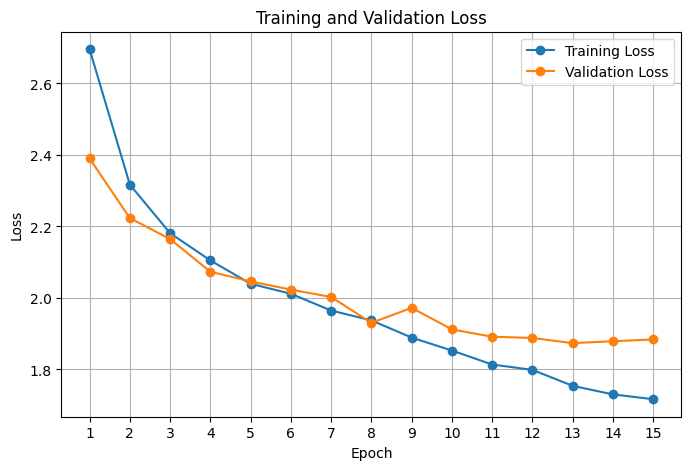

In [55]:
dl.train(15)

Device: cuda
Epoch: 16
Duration: 5 minutes and 16 seconds
Training Loss: 1.7077410385712681
Validation Loss: 1.8587646412562175
✅Best Model saved from epoch 16 with validation loss 1.8587646412562175
Epoch: 17
Duration: 5 minutes and 16 seconds
Training Loss: 1.6931771940632954
Validation Loss: 1.849983516227768
✅Best Model saved from epoch 17 with validation loss 1.849983516227768
Epoch: 18
Duration: 5 minutes and 16 seconds
Training Loss: 1.6831595016105863
Validation Loss: 1.8638217569474715
Epoch: 19
Duration: 5 minutes and 16 seconds
Training Loss: 1.65546309363922
Validation Loss: 1.8330821416464196
✅Best Model saved from epoch 19 with validation loss 1.8330821416464196
Epoch: 20
Duration: 5 minutes and 15 seconds
Training Loss: 1.6481111176661998
Validation Loss: 1.848990683275533
Epoch: 21
Duration: 5 minutes and 15 seconds
Training Loss: 1.6307040348749033
Validation Loss: 1.839104675025825
Epoch: 22
Duration: 5 minutes and 15 seconds
Training Loss: 1.6086381003260612
Validati

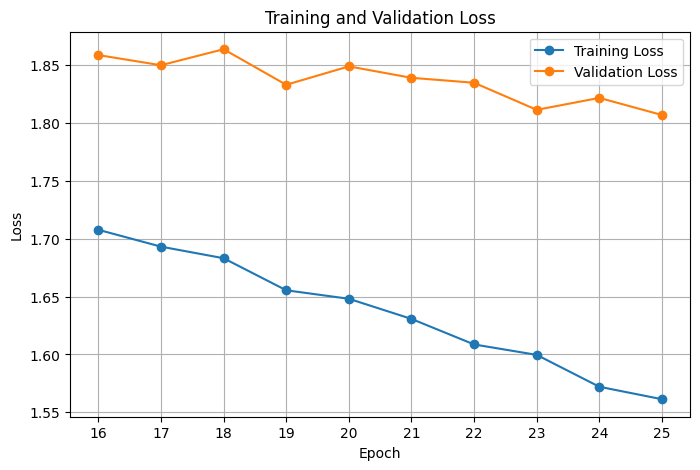

In [56]:
dl.train(10)

In [57]:
def generate_caption(index, max_length=149):

    dl.pick_the_best_model()
    dl.model.eval()

    img, cp = test_dataset[index]

    xray = img.unsqueeze(0).to(dl.device)

    # Start with <BOS>
    generated = [
        word_to_idx["<BOS>"]
    ]
    with torch.no_grad():

        for i in range(max_length):
            decoder_input = torch.tensor(
                generated,
                dtype=torch.long,
                device=dl.device
            ).unsqueeze(0)
            logits = dl.model(
                xray,
                decoder_input
            )
            #print(logits.shape)
            # Prediction for the last generated position
            next_token = torch.argmax(
                logits[:, -1, :],
                dim=-1
            ).item()

            generated.append(next_token)

            if next_token == word_to_idx["<EOS>"]:
                break

    # Convert reference to text
    original_caption = []

    for token_id in cp.tolist():

        word = idx_to_word[token_id]

        if word == "<BOS>":
            continue

        if word == "<PAD>":
            break

        original_caption.append(word)

        if word == "<EOS>":
            break

    # Convert generated tokens to text
    generated_caption = []

    for token_id in generated:

        word = idx_to_word[token_id]

        if word == "<BOS>":
            continue

        if word == "<EOS>":
            break

        generated_caption.append(word)

    print("Original caption:")
    print(" ".join(original_caption))

    print()

    print("Generated caption:")
    print(" ".join(generated_caption))

    #plt.imshow(img[0], cmap="gray")
    #plt.axis("off")
    #plt.show()

In [58]:
for i in range(0,5):
    print("test sample:",i+1)
    generate_caption(i)
    print()

test sample: 1
Original caption:
there is hyperinflation . there is some subtle scarring in the lateral right base . there is no pleural effusion or pneumothorax . the heart is not significantly enlarged . there are atherosclerotic changes of the aorta . arthritic changes of the skeletal structures are noted . <EOS>

Generated caption:
the lungs are clear . the cardiomediastinal silhouette is within normal limits . no pneumothorax or pleural effusion .

test sample: 2
Original caption:
the heart is top normal in size . the mediastinum is stable . aorta is tortuous and atherosclerotic . lungs are mildly hypoinflated . no acute infiltrate is seen . <EOS>

Generated caption:
the lungs are clear . the cardiomediastinal silhouette is within normal limits . no pneumothorax or pleural effusion .

test sample: 3
Original caption:
heart size and mediastinal contour normal . lungs are clear except for residuals of prior granulomatous infection . no pleural effusions or pneumothoraces . <EOS>

Ge

In [ ]:
dl.train(10)

Device: cuda
